# MODEL TRAINING AND EVALUATION

This notebook compares model performance before and after using synthetic data generated by CTGAN.

---

IMPORT LIBRARIES

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

UPLOAD DATASETS

In [4]:
from google.colab import files

uploaded = files.upload()

Saving synthetic_fraud.csv to synthetic_fraud (1).csv
Saving creditcard.csv to creditcard.csv


LOAD DATA

In [6]:
# Load original dataset
data = pd.read_csv("creditcard.csv")

# Load synthetic data
synthetic_fraud = pd.read_csv("synthetic_fraud.csv")

data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Model Training Before Data Augmentation

The model is trained on the original imbalanced dataset.

---

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Original data
X = data.drop('Class', axis=1)
y = data['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("BEFORE AUGMENTATION\n")
print(classification_report(y_test, y_pred))

BEFORE AUGMENTATION

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85307
           1       0.92      0.81      0.86       136

    accuracy                           1.00     85443
   macro avg       0.96      0.90      0.93     85443
weighted avg       1.00      1.00      1.00     85443



## Data Augmentation

Synthetic fraud data is added to balance the dataset.

---

In [8]:
# Combine datasets
augmented_data = pd.concat([data, synthetic_fraud], ignore_index=True)

# Shuffle
augmented_data = augmented_data.sample(frac=1, random_state=42)

## Model Training After Data Augmentation

The model is trained on the balanced dataset.

---

In [9]:
X_aug = augmented_data.drop('Class', axis=1)
y_aug = augmented_data['Class']

X_train, X_test, y_train, y_test = train_test_split(X_aug, y_aug, test_size=0.3, random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("AFTER AUGMENTATION\n")
print(classification_report(y_test, y_pred))

AFTER AUGMENTATION

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85299
           1       1.00      0.99      0.99      1644

    accuracy                           1.00     86943
   macro avg       1.00      0.99      1.00     86943
weighted avg       1.00      1.00      1.00     86943



CONFUSION MATRIX

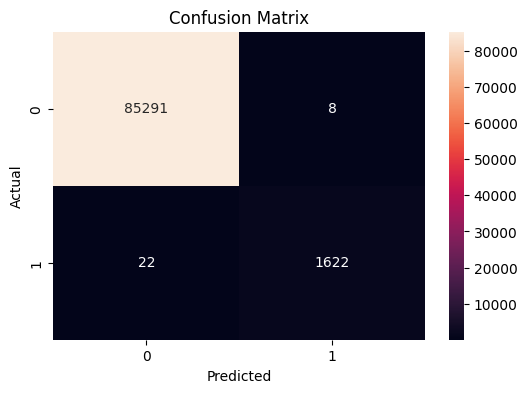

In [10]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

SAVE PLOT

In [11]:
plt.savefig("evaluation_plots.png")

<Figure size 640x480 with 0 Axes>

## FINAL INSIGHTS

- Model performance improved after augmentation  
- Recall for fraud detection increased  
- Synthetic data helped solve class imbalance  

---